In [26]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report 
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.tree import DecisionTreeClassifier
from plotly.subplots import make_subplots
from sklearn.tree import plot_tree
import seaborn as sns

In [2]:
df = pd.read_csv('earthquake_data_tsunami.csv')
df.head()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
0,7.0,8,7,768,117,0.509,17.0,14.000,-9.7963,159.596,2022,11,1
1,6.9,4,4,735,99,2.229,34.0,25.000,-4.9559,100.738,2022,11,0
2,7.0,3,3,755,147,3.125,18.0,579.000,-20.0508,-178.346,2022,11,1
3,7.3,5,5,833,149,1.865,21.0,37.000,-19.2918,-172.129,2022,11,1
4,6.6,0,2,670,131,4.998,27.0,624.464,-25.5948,178.278,2022,11,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 13 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  782 non-null    float64
 1   cdi        782 non-null    int64  
 2   mmi        782 non-null    int64  
 3   sig        782 non-null    int64  
 4   nst        782 non-null    int64  
 5   dmin       782 non-null    float64
 6   gap        782 non-null    float64
 7   depth      782 non-null    float64
 8   latitude   782 non-null    float64
 9   longitude  782 non-null    float64
 10  Year       782 non-null    int64  
 11  Month      782 non-null    int64  
 12  tsunami    782 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 79.6 KB


In [4]:
df.describe()

,magnitude,cdi,mmi,sig,nst,dmin,gap,depth,latitude,longitude,Year,Month,tsunami
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,6.941125,4.333760,5.964194,870.108696,230.250639,1.325757,25.038990,75.883199,3.538100,52.609199,2012.280051,6.563939,0.388747
std,0.445514,3.169939,1.462724,322.465367,250.188177,2.218805,24.225067,137.277078,27.303429,117.898886,6.099439,3.507866,0.487778
min,6.500000,0.000000,1.000000,650.000000,0.000000,0.000000,0.000000,2.700000,-61.848400,-179.968000,2001.000000,1.000000,0.000000
25%,6.600000,0.000000,5.000000,691.000000,0.000000,0.000000,14.625000,14.000000,-14.595600,-71.668050,2007.000000,3.250000,0.000000
50%,6.800000,5.000000,6.000000,754.000000,140.000000,0.000000,20.000000,26.295000,-2.572500,109.426000,2013.000000,7.000000,0.000000
75%,7.100000,7.000000,7.000000,909.750000,445.000000,1.863000,30.000000,49.750000,24.654500,148.941000,2017.000000,10.000000,1.000000
max,9.100000,9.000000,9.000000,2910.000000,934.000000,17.654000,239.000000,670.810000,71.631200,179.662000,2022.000000,12.000000,1.000000


In [5]:
df = df.drop(['Year', 'Month'], axis=1)

In [6]:
fig = make_subplots(rows=1, cols=2, subplot_titles=('Magnitude vs Tsunami', 'Magnitude vs Depth'))
fig.add_trace(px.scatter(df, x='magnitude', y='tsunami').data[0], row=1, col=1)
fig.add_trace(px.scatter(df, x='magnitude', y='depth').data[0], row=1, col=2)
fig.update_layout(height=400, width=800, title_text="Magnitude vs Tsunami e Depth")
fig.show()

In [7]:
geo = px.scatter_geo(df, lat='latitude', lon='longitude', color='tsunami', size='magnitude', title='Ocorrência de Terremotos e Tsunamis')
geo.show()

In [24]:
corr = df.corr()

Text(0.5, 1.0, 'Mapa de Correlação')

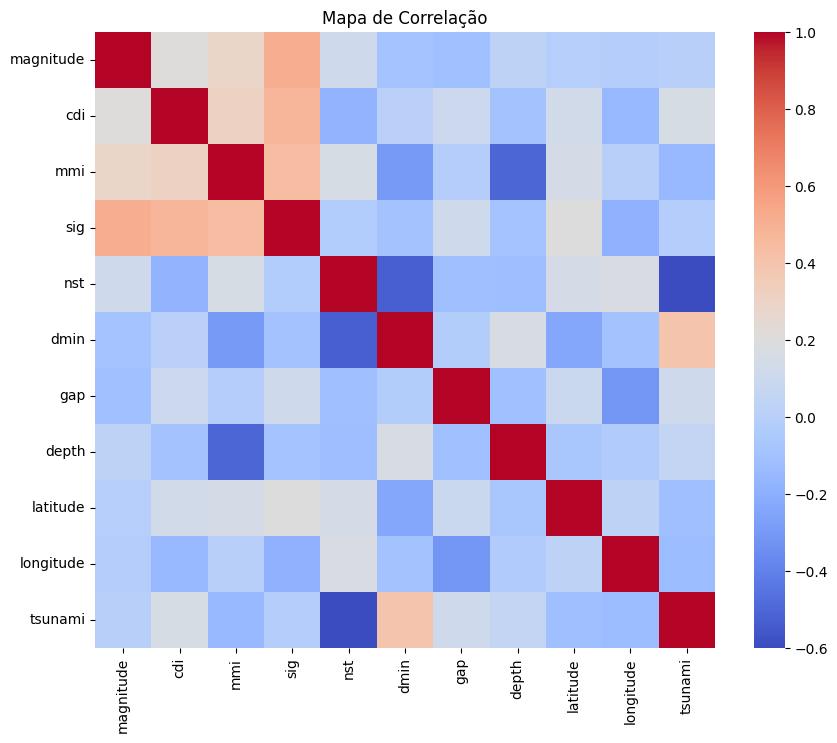

In [29]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Mapa de Correlação')

In [8]:
x = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

In [9]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
len(x_train), len(y_test)

(625, 157)

In [11]:
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [12]:
dt = DecisionTreeClassifier(random_state=42, max_depth=5, criterion='entropy')
dt.fit(x_train, y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [13]:
y_pred_dt = dt.predict(x_test)

[Text(0.5277777777777778, 0.9166666666666666, 'x[5] <= -0.57\nentropy = 0.959\nsamples = 625\nvalue = [387.0, 238.0]'),
 Text(0.2847222222222222, 0.75, 'x[8] <= 1.806\nentropy = 0.387\nsamples = 330\nvalue = [305, 25]'),
 Text(0.40625, 0.8333333333333333, 'True  '),
 Text(0.18055555555555555, 0.5833333333333334, 'x[9] <= 0.791\nentropy = 0.316\nsamples = 315\nvalue = [297, 18]'),
 Text(0.1111111111111111, 0.4166666666666667, 'x[9] <= -0.58\nentropy = 0.212\nsamples = 239\nvalue = [231.0, 8.0]'),
 Text(0.05555555555555555, 0.25, 'x[9] <= -0.859\nentropy = 0.418\nsamples = 71\nvalue = [65, 6]'),
 Text(0.027777777777777776, 0.08333333333333333, 'entropy = 0.319\nsamples = 69\nvalue = [65, 4]'),
 Text(0.08333333333333333, 0.08333333333333333, 'entropy = 0.0\nsamples = 2\nvalue = [0, 2]'),
 Text(0.16666666666666666, 0.25, 'x[8] <= -0.241\nentropy = 0.093\nsamples = 168\nvalue = [166, 2]'),
 Text(0.1388888888888889, 0.08333333333333333, 'entropy = 0.292\nsamples = 39\nvalue = [37, 2]'),
 Tex

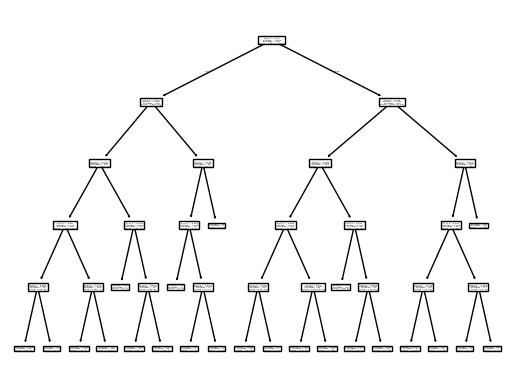

In [14]:
plot_tree(dt)

In [15]:
lr = LogisticRegression(random_state=42)
lr.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [16]:
y_pred_lr = lr.predict(x_test)

In [17]:
random_forest = RandomForestClassifier(random_state=42, criterion='entropy')
random_forest.fit(x_train, y_train)

,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
y_pred_rf = random_forest.predict(x_test)

In [19]:
cr_lr = classification_report(y_test, y_pred_lr)
cr_rf = classification_report(y_test, y_pred_rf)
cr_dt = classification_report(y_test, y_pred_dt)
print("Classification Report para Logistic Regression:")
print(cr_lr)

Classification Report para Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83        91
           1       0.75      0.85      0.79        66

    accuracy                           0.82       157
   macro avg       0.81      0.82      0.81       157
weighted avg       0.82      0.82      0.82       157



In [20]:
print("Classification Report para Random Forest:")
print(cr_rf)

Classification Report para Random Forest:
              precision    recall  f1-score   support

           0       0.95      0.92      0.94        91
           1       0.90      0.94      0.92        66

    accuracy                           0.93       157
   macro avg       0.93      0.93      0.93       157
weighted avg       0.93      0.93      0.93       157



In [21]:
print("\nClassification Report para Decision Tree:")
print(cr_dt)


Classification Report para Decision Tree:
              precision    recall  f1-score   support

           0       0.94      0.91      0.93        91
           1       0.88      0.92      0.90        66

    accuracy                           0.92       157
   macro avg       0.91      0.92      0.92       157
weighted avg       0.92      0.92      0.92       157

